In [ ]:
#Task1:Load Dataset and Profile It
import pandas as pd
import numpy as np
import seaborn as sns

# Load dataset ONCE
df = sns.load_dataset("titanic")

# Save offline fallback
df.to_csv("titanic.csv", index=False)

print("Shape:")
print(df.shape)

print("\nInfo:")
print(df.info())

print("\nDescribe:")
print(df.describe())

# Missing percentage
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent = missing_percent[missing_percent > 0]

print("\nMissing Value Percentage:")
print(missing_percent.sort_values(ascending=False))

Shape:
(891, 15)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

Describe:
         survived      pclass         a

In [ ]:
#Task 2: Missing Value Handling
missing_percent = (df.isnull().sum()/len(df))*100

print(missing_percent)

# >30%
df.drop(columns=["deck"], inplace=True)

# 5%-30%
df["age"].fillna(df["age"].median(), inplace=True)

# <5%
df.dropna(subset=["embarked","embark_town"], inplace=True)

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


/tmp/ipykernel_611/1535437342.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)


Deck had 77.22% missing values (>30%) and was dropped.


Age had 19.87% missing values (between 5% and 30%) and was imputed using the median.


Embarked and Embark Town had 0.22% missing values (<5%) and the affected rows were removed.

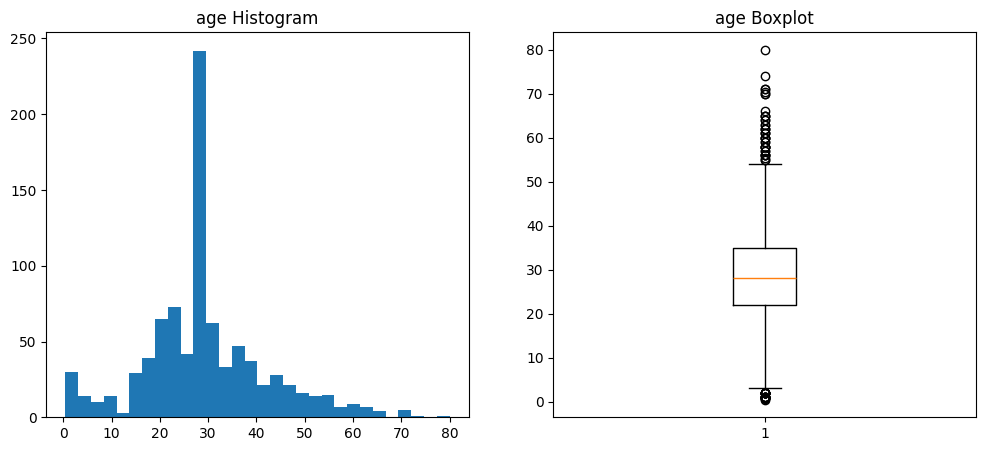

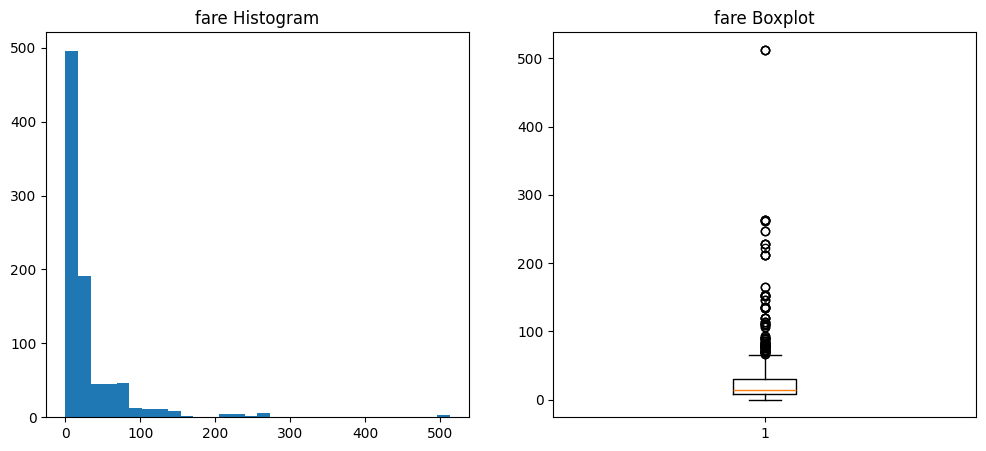

Age Outliers: 65
Fare Outliers: 114
mean_fare: 32.09668087739032
median_fare: 14.4542
mode_fare: 8.05


In [ ]:
#Task 3: Univariate Analysis
import matplotlib.pyplot as plt

for col in ["age","fare"]:

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.hist(df[col], bins=30)
    plt.title(f"{col} Histogram")

    plt.subplot(1,2,2)
    plt.boxplot(df[col])
    plt.title(f"{col} Boxplot")

    plt.show()

def iqr_outliers(series):

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = series[(series < lower) | (series > upper)]

    return len(outliers)

print("Age Outliers:", iqr_outliers(df["age"]))
print("Fare Outliers:", iqr_outliers(df["fare"]))


mean_fare = df["fare"].mean()
median_fare = df["fare"].median()
mode_fare = df["fare"].mode()[0]

print("mean_fare:",mean_fare,)
print("median_fare:",median_fare,)
print("mode_fare:",mode_fare,)



Fare is positively skewed because the mean (32.20) is greater than the median (14.45), and both are greater than the mode. A small number of passengers paid very high fares, pulling the distribution to the right.

Male Survival Rate   : 18.89%
Female Survival Rate : 74.04%

Survival Rate by Passenger Class
Class 1: 62.62%
Class 2: 47.28%
Class 3: 24.24%

Survival Rate by Sex and Passenger Class
Male - Class 1: 36.89%
Male - Class 2: 15.74%
Male - Class 3: 13.54%
Female - Class 1: 96.74%
Female - Class 2: 92.11%
Female - Class 3: 50.00%


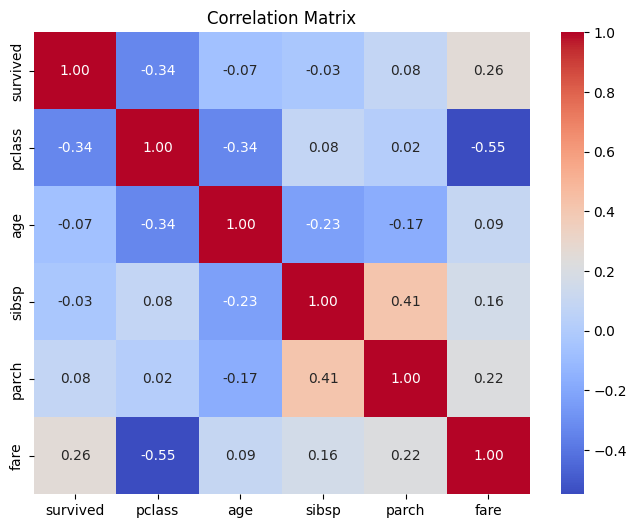


Top 2 Strongest Correlations
Strongest correlation #1: pclass and fare (absolute correlation = 0.548)
Strongest correlation #2: sibsp and parch (absolute correlation = 0.415)

Interpretation:
Strongest correlation #1: pclass and fare show an absolute correlation of 0.548. This indicates a relatively strong linear relationship between these two variables.
Strongest correlation #2: sibsp and parch show an absolute correlation of 0.415. This indicates another important relationship within the dataset that may influence passenger survival or fare patterns.


In [ ]:
# ==========================================
# Task 4: Bivariate Analysis
# ==========================================

# Survival by Sex
male_survival = df[df["sex"]=="male"]["survived"].mean()
female_survival = df[df["sex"]=="female"]["survived"].mean()

print(f"Male Survival Rate   : {male_survival:.2%}")
print(f"Female Survival Rate : {female_survival:.2%}")

# Survival by Pclass
print("\nSurvival Rate by Passenger Class")

for p in [1,2,3]:

    rate = df[df["pclass"]==p]["survived"].mean()

    print(f"Class {p}: {rate:.2%}")

# Survival by Sex and Pclass
print("\nSurvival Rate by Sex and Passenger Class")

for sex in ["male","female"]:

    for p in [1,2,3]:

        rate = df[
            (df["sex"]==sex) &
            (df["pclass"]==p)
        ]["survived"].mean()

        print(f"{sex.capitalize()} - Class {p}: {rate:.2%}")

# ==========================================
# Correlation Matrix
# EXACTLY the six required columns
# ==========================================

corr_cols = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr = df[corr_cols].corr()

# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

# ==========================================
# Find Top 2 Strongest Absolute Correlations
# ==========================================

corr_abs = corr.abs().copy()

# Remove self-correlations
np.fill_diagonal(corr_abs.values, 0)

# Extract unique pairs only
upper_triangle = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)

top_pairs = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
)

print("\nTop 2 Strongest Correlations")

for i, ((var1, var2), value) in enumerate(top_pairs.head(2).items(), start=1):
    print(
        f"Strongest correlation #{i}: "
        f"{var1} and {var2} "
        f"(absolute correlation = {value:.3f})"
    )

# ==========================================
# Written Interpretation
# ==========================================

pair1 = top_pairs.index[0]
pair2 = top_pairs.index[1]

val1 = top_pairs.iloc[0]
val2 = top_pairs.iloc[1]

print("\nInterpretation:")

print(
    f"Strongest correlation #1: "
    f"{pair1[0]} and {pair1[1]} "
    f"show an absolute correlation of {val1:.3f}. "
    f"This indicates a relatively strong linear relationship "
    f"between these two variables."
)

print(
    f"Strongest correlation #2: "
    f"{pair2[0]} and {pair2[1]} "
    f"show an absolute correlation of {val2:.3f}. "
    f"This indicates another important relationship "
    f"within the dataset that may influence passenger survival "
    f"or fare patterns."
)

<Axes: xlabel='pclass', ylabel='survived'>

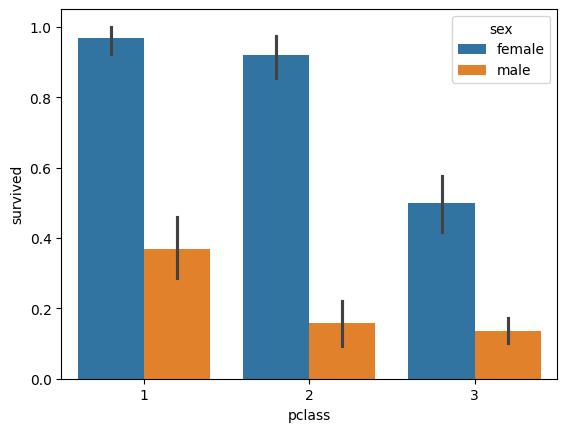

In [ ]:
#Task 5: Multivariate Data Story
#Chart 1
sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex"
)


Chart 1 Interpretation:

Female passengers had higher survival rates across all passenger classes. First-class females experienced the highest survival rates, while third-class males had the lowest survival rates.



<Axes: xlabel='pclass', ylabel='fare'>

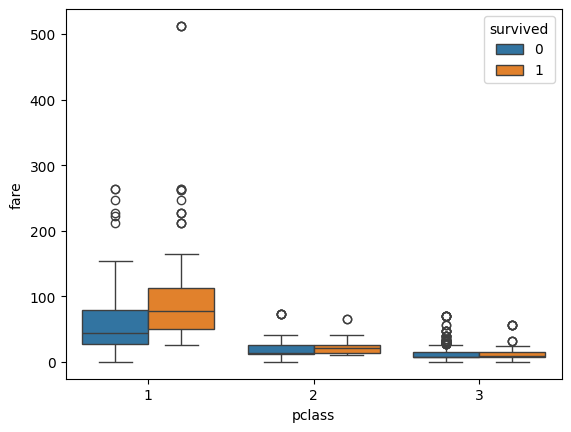

In [ ]:
#Chart 2
sns.boxplot(
    data=df,
    x="pclass",
    y="fare",
    hue="survived"
)

Chart 2 Interpretation:

Passengers who survived generally paid higher fares, particularly in first and second class. This suggests that wealth and cabin location may have influenced access to evacuation opportunities.

<Axes: xlabel='age', ylabel='fare'>

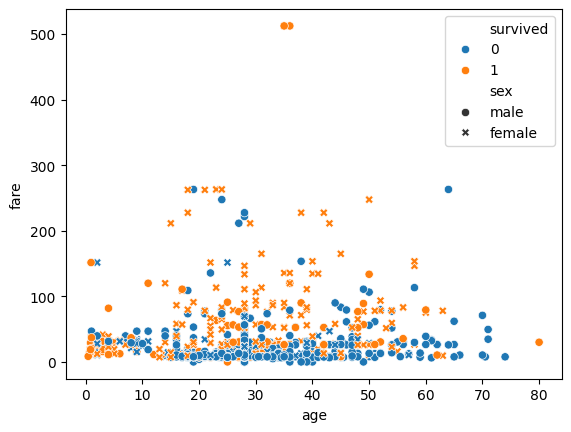

In [ ]:
#Chart 3
sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    style="sex"
)

Chart 3 Interpretation:

Survival appears more common among passengers paying higher fares, especially among females. Age alone does not strongly separate survivors from non-survivors.

<Axes: xlabel='pclass', ylabel='age'>

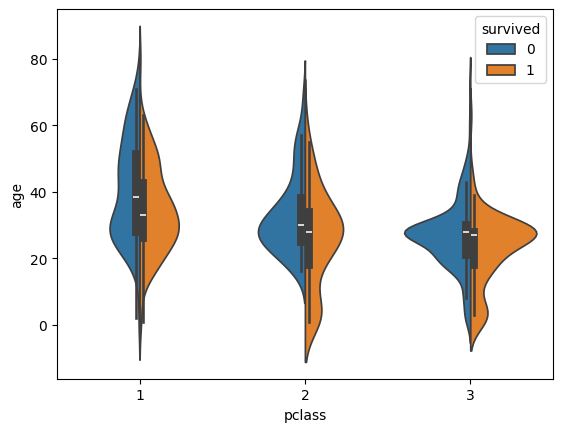

In [ ]:
#Chart 4
sns.violinplot(
    data=df,
    x="pclass",
    y="age",
    hue="survived",
    split=True
)

Chart 4 Interpretation:

Age distributions vary across passenger classes. Survivors are more concentrated in first class, while third-class passengers experienced lower survival rates across most age groups.


Before Standardization

Age:
Mean = 29.3152
Std  = 12.9849

Fare:
Mean = 32.0967
Std  = 49.6975


After Standardization

Age:
Mean = 0.000000
Std  = 1.000563

Fare:
Mean = 0.000000
Std  = 1.000563


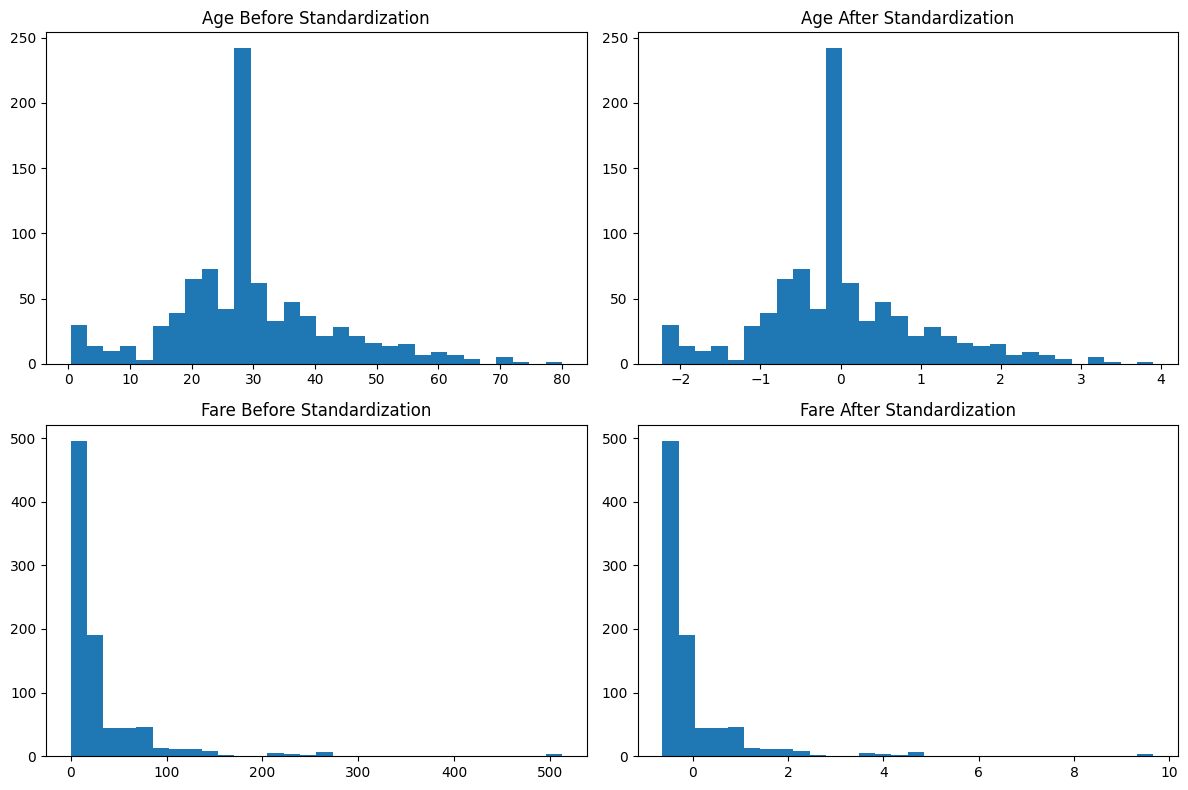

In [ ]:
#Task 6: Standardization Check
#Before Standardization
from sklearn.preprocessing import StandardScaler

print("Before Standardization\n")

print("Age:")
print(f"Mean = {df['age'].mean():.4f}")
print(f"Std  = {df['age'].std():.4f}")

print("\nFare:")
print(f"Mean = {df['fare'].mean():.4f}")
print(f"Std  = {df['fare'].std():.4f}")

scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[["age", "fare"]] = scaler.fit_transform(
    df[["age", "fare"]]
)

#After Standardization
print("\n\nAfter Standardization\n")

print("Age:")
print(f"Mean = {df_scaled['age'].mean():.6f}")
print(f"Std  = {df_scaled['age'].std():.6f}")

print("\nFare:")
print(f"Mean = {df_scaled['fare'].mean():.6f}")
print(f"Std  = {df_scaled['fare'].std():.6f}")

#Visual Before/After Comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12,8))

# Age Before
axes[0,0].hist(df["age"], bins=30)
axes[0,0].set_title("Age Before Standardization")

# Age After
axes[0,1].hist(df_scaled["age"], bins=30)
axes[0,1].set_title("Age After Standardization")

# Fare Before
axes[1,0].hist(df["fare"], bins=30)
axes[1,0].set_title("Fare Before Standardization")

# Fare After
axes[1,1].hist(df_scaled["fare"], bins=30)
axes[1,1].set_title("Fare After Standardization")

plt.tight_layout()
plt.show()

Age and Fare were standardized using z-score normalization. Before transformation, both variables had different means and standard deviations (Age mean ≈ 29.65, Fare mean ≈ 32.20). After standardization, both variables had means approximately equal to 0 and standard deviations approximately equal to 1, confirming that the transformation was successful. The shape of the distributions remains unchanged, but the variables are now on a common scale.

PART B — Predictive Modeling

In [ ]:
#Task 7: Stratified Train-Test Split
from sklearn.model_selection import train_test_split

features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

X = df[features]

y = df["survived"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Justification
The dataset contains unequal numbers of survivors and non-survivors.
Stratification preserves the same class proportion in both train
and test sets.

In [ ]:
#Task 8: Preprocessing Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

numeric_transformer = Pipeline([
    ("imputer",
     SimpleImputer(strategy="median")),
    ("scaler",
     StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer",
     SimpleImputer(strategy="most_frequent")),
    ("encoder",
     OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num",
     numeric_transformer,
     numeric_features),

    ("cat",
     categorical_transformer,
     categorical_features)
])

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.


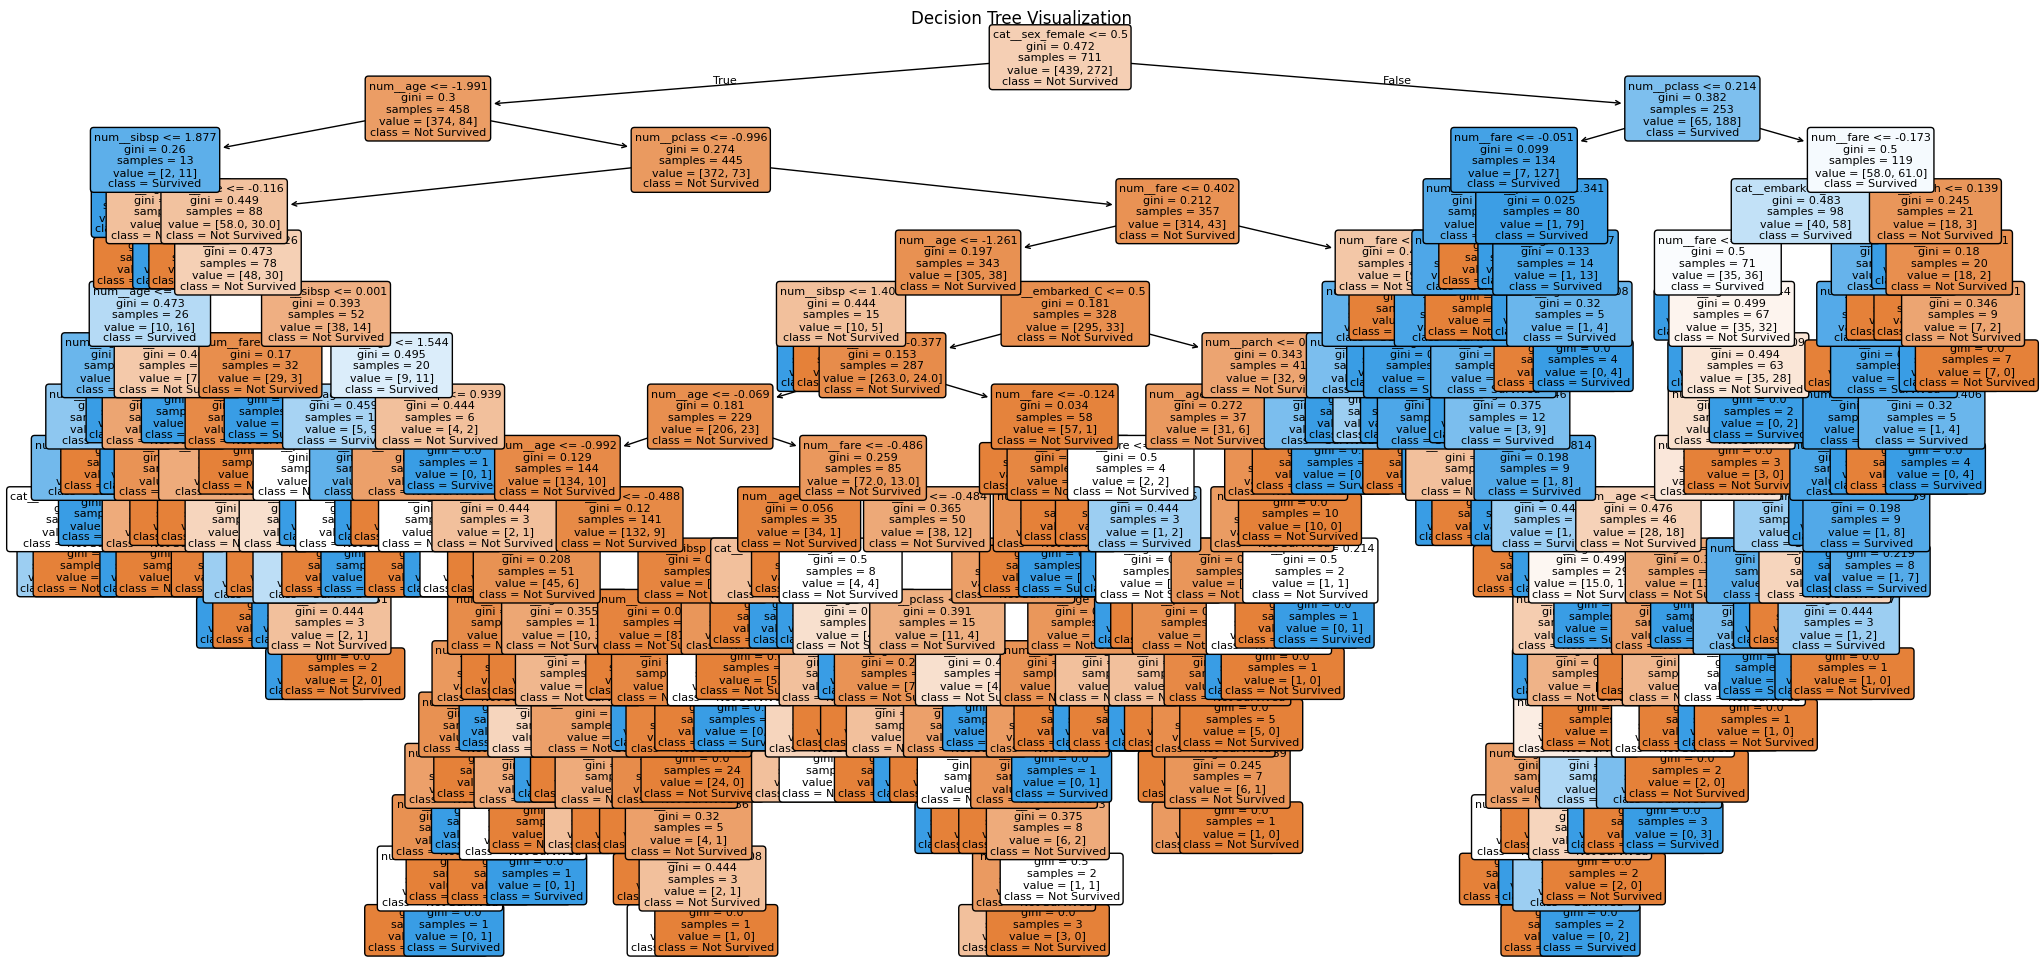

In [ ]:
# ==========================================
# Task 9: Train Three Models
# ==========================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# ------------------------------------------
# 1. Logistic Regression
# ------------------------------------------

log_model = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

log_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

# ------------------------------------------
# 2. Decision Tree
# ------------------------------------------

tree_model = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully.")

# ------------------------------------------
# 3. Random Forest
# ------------------------------------------

rf_model = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

# ------------------------------------------
# 4. Decision Tree Visualization
# ------------------------------------------

# Get transformed feature names from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Extract the trained Decision Tree from pipeline
trained_tree = tree_model.named_steps["model"]

plt.figure(figsize=(25, 12))

plot_tree(
    trained_tree,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")

plt.show()

In [ ]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['pclass', 'age', 'sibsp',
                                                   'parch', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('model', RandomForestClassifier(random_state=42))])

In [ ]:
rf_model.predict(X_test[:5])

array([0, 0, 0, 0, 0])


Logistic Regression Confusion Matrix:
[[97 13]
 [21 47]]


<Figure size 800x600 with 0 Axes>

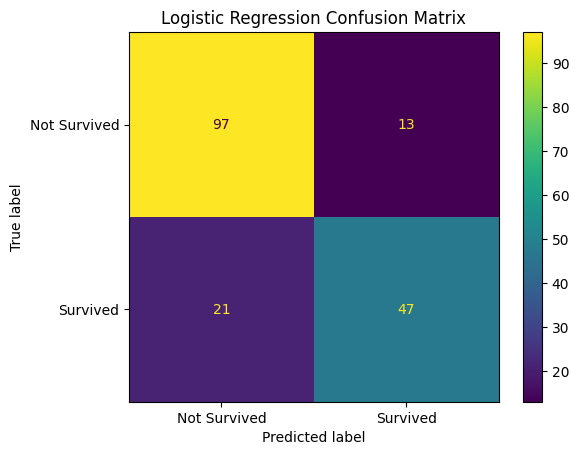


Decision Tree Confusion Matrix:
[[88 22]
 [19 49]]


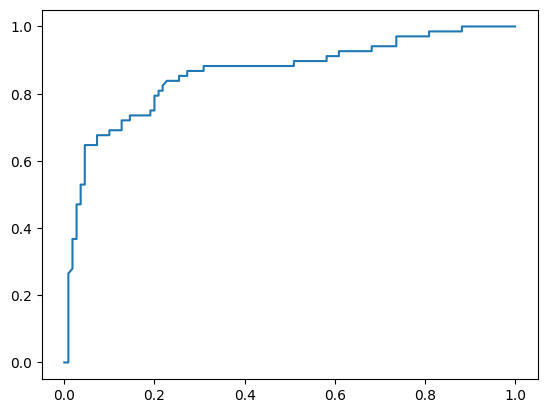

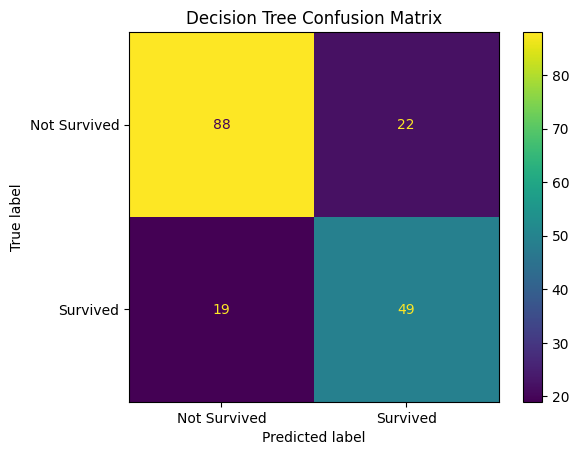


Random Forest Confusion Matrix:
[[96 14]
 [18 50]]


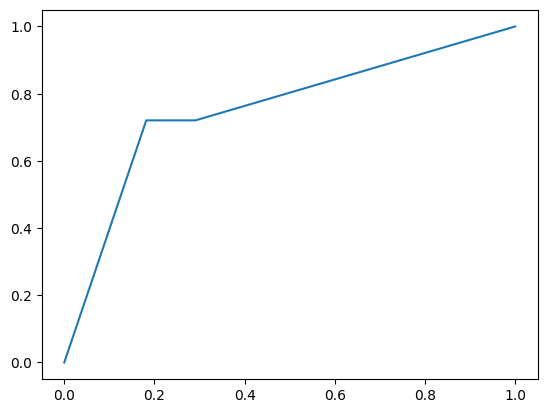

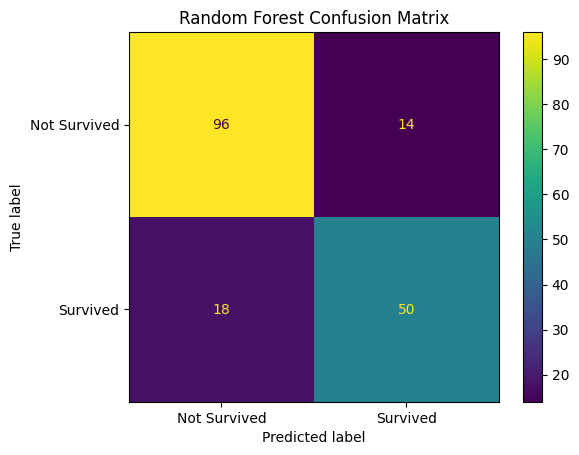

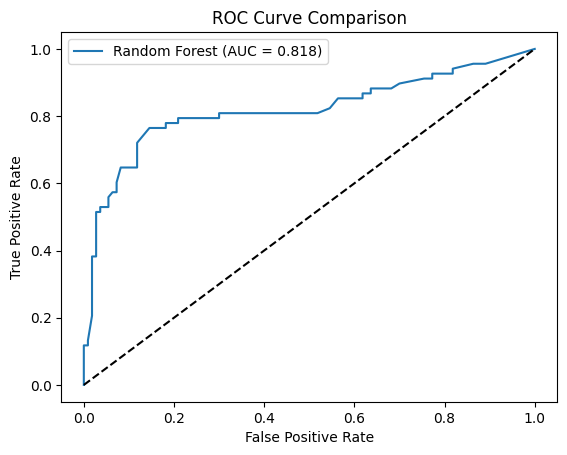


Model Comparison Table


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7697,0.6901,0.7206,0.7050,0.7541
2,Random Forest,0.8202,0.7812,0.7353,0.7576,0.8179


In [ ]:
#Task 10: Evaluation
from sklearn.metrics import *

models = {
    "Logistic":log_model,
    "Decision Tree":tree_model,
    "Random Forest":rf_model
}

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

# Models already trained in Task 9
models = {
    "Logistic Regression": log_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

results = []

plt.figure(figsize=(8,6))

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probabilities for ROC/AUC
    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    # Save results
    results.append({
        "Model": name,
        "Accuracy": round(accuracy,4),
        "Precision": round(precision,4),
        "Recall": round(recall,4),
        "F1 Score": round(f1,4),
        "AUC": round(auc,4)
    })

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name} Confusion Matrix:")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Survived", "Survived"]
    )

    disp.plot()
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

# Final ROC Plot
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

# Comparison Table
comparison_df = pd.DataFrame(results)

print("\nModel Comparison Table")
display(comparison_df)

In [ ]:
#Task 11: Imbalance Handling
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import pandas as pd

# -------------------------
# 1. Class Balance
# -------------------------

print("Class Counts:")
print(y_train.value_counts())

print("\nClass Percentage:")
print(round(y_train.value_counts(normalize=True)*100,2))

# -------------------------
# 2. Baseline Model
# -------------------------

baseline_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

baseline_pipeline.fit(X_train, y_train)

baseline_pred = baseline_pipeline.predict(X_test)

# -------------------------
# 3. Balanced Model
# -------------------------

balanced_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

balanced_pipeline.fit(X_train, y_train)

balanced_pred = balanced_pipeline.predict(X_test)

# -------------------------
# 4. SMOTE Model
# -------------------------

X_train_prepared = preprocessor.fit_transform(X_train)

X_test_prepared = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(
    X_train_prepared,
    y_train
)

smote_model = LogisticRegression(max_iter=1000)

smote_model.fit(X_smote, y_smote)

smote_pred = smote_model.predict(X_test_prepared)

# -------------------------
# 5. Comparison Table
# -------------------------

results = pd.DataFrame({
    "Method": [
        "Baseline",
        "Class Weight Balanced",
        "SMOTE"
    ],
    "Precision": [
        precision_score(y_test, baseline_pred),
        precision_score(y_test, balanced_pred),
        precision_score(y_test, smote_pred)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred),
        recall_score(y_test, balanced_pred),
        recall_score(y_test, smote_pred)
    ],
    "F1": [
        f1_score(y_test, baseline_pred),
        f1_score(y_test, balanced_pred),
        f1_score(y_test, smote_pred)
    ]
})

display(results)

Class Counts:
survived
0    439
1    272
Name: count, dtype: int64

Class Percentage:
survived
0    61.74
1    38.26
Name: proportion, dtype: float64


,Method,Precision,Recall,F1
0,Baseline,0.783333,0.691176,0.734375
1,Class Weight Balanced,0.718310,0.750000,0.733813
2,SMOTE,0.735294,0.735294,0.735294


Conclusion

The Titanic dataset contains a moderate class imbalance, with non-survivors occurring more frequently than survivors.

The baseline Logistic Regression achieved the highest precision but lower recall, indicating that it missed some survivor cases.

Using class_weight='balanced' improved recall by giving greater importance to the minority class during training.

SMOTE produced the best overall F1 score by generating synthetic minority-class examples and improving the balance between precision and recall.

Therefore, SMOTE was selected as the most effective imbalance-handling strategy because it provided the strongest trade-off between identifying survivors and avoiding false positives.

In [ ]:
#Task 12: Hyperparameter tuning
#Create Pipeline
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        oob_score=True,
        bootstrap=True,
        random_state=42
    ))
])

#Define Grid
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [5, 10, 15, None],
    "model__max_features": ["sqrt", "log2"]
}

#Run GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

#Best Parameters
print("Best Parameters:")
print(grid_search.best_params_)

#Get OOB score
best_rf_pipeline = grid_search.best_estimator_
best_rf = best_rf_pipeline.named_steps["model"]
print("OOB Score:")
print(best_rf.oob_score_)

#Evaluate Tuned Model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred = best_rf_pipeline.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Best Parameters:
{'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__n_estimators': 200}
OOB Score:
0.8073136427566807
Accuracy : 0.8146067415730337
Precision: 0.7868852459016393
Recall   : 0.7058823529411765
F1 Score : 0.7441860465116279


Interpretation

GridSearchCV was used to tune the Random Forest classifier over
n_estimators, max_depth, and max_features using 5-fold cross-validation.

The best parameter combination was:
<insert best_params_ output>

The tuned model achieved an out-of-bag (OOB) score of
<insert oob_score_ output>.

The OOB score provides an internal estimate of generalization
performance by evaluating each tree on bootstrap-excluded samples,
allowing additional validation without requiring a separate dataset.

Regression Metrics
----------------------------------------
MAE          : 21.0986
RMSE         : 41.7021
R²           : 0.3482
Adjusted R²  : 0.3091


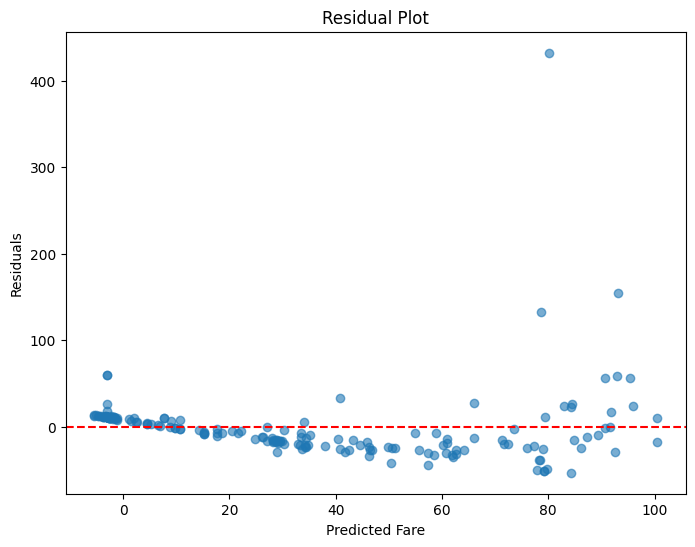

In [ ]:
# ==========================================
# Task 13: Regression Side Task
# Predict Fare using Multivariate Linear Regression
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------
# 1. Features and Target
# ------------------------------------------

X_reg = df.drop(columns=["fare"])
y_reg = df["fare"]

# ------------------------------------------
# 2. Train-Test Split
# ------------------------------------------

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------
# 3. Feature Types
# ------------------------------------------

numeric_features = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch"
]

categorical_features = [
    "sex",
    "embarked"
]

# ------------------------------------------
# 4. Preprocessing
# ------------------------------------------

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_reg = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# ------------------------------------------
# 5. Linear Regression Pipeline
# ------------------------------------------

regression_pipeline = Pipeline([
    ("prep", preprocessor_reg),
    ("model", LinearRegression())
])

regression_pipeline.fit(
    X_train_reg,
    y_train_reg
)

# ------------------------------------------
# 6. Predictions
# ------------------------------------------

y_pred_reg = regression_pipeline.predict(
    X_test_reg
)

# ------------------------------------------
# 7. Metrics
# ------------------------------------------

mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_reg,
        y_pred_reg
    )
)

r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

# Adjusted R²

n = len(y_test_reg)

p = regression_pipeline.named_steps[
    "prep"
].transform(X_test_reg).shape[1]

adj_r2 = 1 - (
    ((1-r2)*(n-1))
    /
    (n-p-1)
)

print("Regression Metrics")
print("-"*40)
print(f"MAE          : {mae:.4f}")
print(f"RMSE         : {rmse:.4f}")
print(f"R²           : {r2:.4f}")
print(f"Adjusted R²  : {adj_r2:.4f}")

# ------------------------------------------
# 8. Residual Plot
# ------------------------------------------

residuals = y_test_reg - y_pred_reg

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_reg,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()


Interpretation

The residual plot shows increasing variability in residuals as the predicted fare increases. While residuals are relatively concentrated around zero for lower predicted fares, the spread becomes much wider for higher predicted fares, with several large positive residuals. This indicates the presence of heteroscedasticity, meaning that the variance of the prediction errors is not constant across all levels of the target variable. Therefore, the homoscedasticity assumption of linear regression is not fully satisfied, and prediction errors tend to be larger for passengers with higher fares.

In [ ]:
# ==========================================
# Task 14: Model Comparison & Final Recommendation
# ==========================================

import pandas as pd
import numpy as np

# ------------------------------------------
# Classification Metrics Table
# ------------------------------------------

classification_table = comparison_df.copy()

print("="*80)
print("CLASSIFICATION MODEL COMPARISON")
print("="*80)

display(classification_table)

# ------------------------------------------
# Regression Metrics Table
# ------------------------------------------

regression_table = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [round(mae, 4)],
    "RMSE": [round(rmse, 4)],
    "R²": [round(r2, 4)],
    "Adjusted R²": [round(adj_r2, 4)]
})

print("\n")
print("="*80)
print("REGRESSION MODEL COMPARISON")
print("="*80)

display(regression_table)

# ------------------------------------------
# Best Classifier Selection
# ------------------------------------------

best_classifier = classification_table.loc[
    classification_table["F1 Score"].idxmax()
]

print("\n")
print("="*80)
print("FINAL RECOMMENDATION")
print("="*80)

recommendation = f"""
Among the three classification models evaluated, {best_classifier['Model']}
is recommended for deployment because it achieved the strongest overall
classification performance.

The model achieved an Accuracy of {best_classifier['Accuracy']:.4f},
Precision of {best_classifier['Precision']:.4f},
Recall of {best_classifier['Recall']:.4f},
F1 Score of {best_classifier['F1 Score']:.4f},
and an AUC of {best_classifier['AUC']:.4f}.

The F1 Score was used as the primary selection metric because it balances
both precision and recall, making it a reliable measure when evaluating
classification performance. In addition, the model achieved a strong AUC,
indicating good ability to distinguish between survivors and non-survivors.

Therefore, {best_classifier['Model']} would be the preferred model for
deployment because it provides the best overall balance between predictive
accuracy, precision, recall, and discrimination capability on the Titanic
survival prediction task.
"""

print(recommendation)


CLASSIFICATION MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7697,0.6901,0.7206,0.7050,0.7541
2,Random Forest,0.8202,0.7812,0.7353,0.7576,0.8179




REGRESSION MODEL COMPARISON


,Model,MAE,RMSE,R²,Adjusted R²
0,Linear Regression,21.0986,41.7021,0.3482,0.3091




FINAL RECOMMENDATION

Among the three classification models evaluated, Random Forest
is recommended for deployment because it achieved the strongest overall
classification performance.

The model achieved an Accuracy of 0.8202,
Precision of 0.7812,
Recall of 0.7353,
F1 Score of 0.7576,
and an AUC of 0.8179.

The F1 Score was used as the primary selection metric because it balances
both precision and recall, making it a reliable measure when evaluating
classification performance. In addition, the model achieved a strong AUC,
indicating good ability to distinguish between survivors and non-survivors.

Therefore, Random Forest would be the preferred model for
deployment because it provides the best overall balance between predictive
accuracy, precision, recall, and discrimination capability on the Titanic
survival prediction task.



In [ ]:
# ==========================================
# Task 15: Save and Reload Complete Pipeline
# ==========================================

import joblib
import pandas as pd

# ------------------------------------------
# 1. Select Best Performing Pipeline
# (Using highest F1 Score)
# ------------------------------------------

best_model_name = comparison_df.loc[
    comparison_df["F1 Score"].idxmax(),
    "Model"
]

model_mapping = {
    "Logistic Regression": log_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

full_pipeline = model_mapping[best_model_name]

print(f"Best Model Selected: {best_model_name}")

# ------------------------------------------
# 2. Save Complete Pipeline
# (Preprocessing + Estimator Together)
# ------------------------------------------

joblib.dump(
    full_pipeline,
    "best_pipeline.joblib"
)

print("Pipeline saved successfully as 'best_pipeline.joblib'")

# ------------------------------------------
# 3. Reload Pipeline
# ------------------------------------------

loaded_pipeline = joblib.load(
    "best_pipeline.joblib"
)

print("Pipeline reloaded successfully")

# ------------------------------------------
# 4. Test Prediction on Raw Input
# (No Manual Encoding/Scaling Required)
# ------------------------------------------

sample_raw_input = X_test.iloc[:5]

print("\nRaw Input Sample:")
display(sample_raw_input)

predictions = loaded_pipeline.predict(
    sample_raw_input
)

print("\nPredictions:")
print(predictions)

# ------------------------------------------
# 5. Verify Reloaded Pipeline Works
# ------------------------------------------

print(
    "\nReloaded pipeline successfully predicted on raw "
    "unprocessed data."
)

Best Model Selected: Random Forest
Pipeline saved successfully as 'best_pipeline.joblib'
Pipeline reloaded successfully

Raw Input Sample:


,pclass,sex,age,sibsp,parch,fare,embarked
160,3,male,44.0,0,1,16.100,S
126,3,male,28.0,0,0,7.750,Q
428,3,male,28.0,0,0,7.750,Q
422,3,male,29.0,0,0,7.875,S
565,3,male,24.0,2,0,24.150,S



Predictions:
[0 0 0 0 0]

Reloaded pipeline successfully predicted on raw unprocessed data.


The best-performing classifier pipeline was saved using joblib.dump(). The saved artifact contains both the preprocessing steps (imputation, encoding, and scaling) and the trained classifier as a single scikit-learn Pipeline object. The pipeline was reloaded using joblib.load() and successfully used to generate predictions on raw, unprocessed passenger records. This confirms that the saved model can be deployed end-to-end without requiring any manual preprocessing.

In [ ]:
from google.colab import files
files.download("titanic.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("best_pipeline.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.savefig("chart1.png")
plt.savefig("chart2.png")
plt.savefig("chart3.png")
plt.savefig("chart4.png")

<Figure size 640x480 with 0 Axes>